In [172]:
import pandas as pd
import matplotlib.pyplot as plt

In [187]:
df = pd.read_csv("Dataset_1.csv")
df.shape
# df.info()
# df.isnull().sum()
# df.head()
df.columns


Index(['accident_id', 'accident_datetime', 'state', 'district', 'area_type',
       'latitude', 'longitude', 'road_type', 'road_condition', 'road_lighting',
       'number_of_lanes', 'speed_limit_kmph', 'estimated_speed_kmph',
       'junction_type', 'traffic_signal_present', 'median_present',
       'weather_condition', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driver_gender', 'driving_experience_years',
       'license_status', 'alcohol_involved', 'distraction_involved',
       'mobile_phone_used', 'fatigue_involved', 'helmet_seatbelt_used',
       'vehicle_type', 'vehicle_age_years', 'vehicle_brand', 'vehicle_model',
       'vehicle_condition', 'overloading_status', 'primary_cause',
       'secondary_cause', 'emergency_services_called', 'ambulance_called',
       'police_called', 'response_time_minutes', 'hospitalization_required',
       'num_vehicles', 'num_injuries', 'num_fatalities', 'accident_severity',
       'insurance_claim_filed', 'insurance_cla

In [174]:
df.drop_duplicates(inplace=True)
df.shape

(201020, 48)

In [175]:
# Handle missing data
from sklearn.impute import SimpleImputer

mean_cols = ["latitude", "longitude" , "speed_limit_kmph" , "visibility_km" , "temperature_c" , "driver_age","driving_experience_years","vehicle_age_years","response_time_minutes" , "insurance_claim_amount"]
imp_mean = SimpleImputer(strategy="mean")
df[mean_cols] = imp_mean.fit_transform(df[mean_cols])


most_freq_cols = ["weather_condition" , "junction_type" , "vehicle_brand" , "secondary_cause" , "vehicle_model","number_of_lanes" ,"overloading_status" , "median_present" ,"hospitalization_required" , "driver_gender" , "district" , "traffic_signal_present" ,"road_lighting"]
imp_freq = SimpleImputer(strategy="most_frequent")
df[most_freq_cols] = imp_freq.fit_transform(df[most_freq_cols])

imp_random = SimpleImputer(strategy="random")

In [ ]:
#  Label Encoding 

df["median_present"] = df["median_present"].map({"Yes": 1, "No": 0,"Y": 1, "N": 0,"True": 1, "False": 0})
df["traffic_signal_present"] = df["traffic_signal_present"].map({"Yes": 1, "No": 0,"Y": 1, "N": 0,"True": 1, "False": 0})
df["mobile_phone_used"] = df["mobile_phone_used"].map({"Yes": 1, "No": 0,"Y": 1, "N": 0,"True": 1, "False": 0})
df["road_type"] = df["road_type"].map({'State Highway':'State Highway','Other District Road' 'National Highway' 'Village Road'
 'Expressway','state highway':'State Highway', 'village road' 'NATIONAL HIGHWAY'
 ' National Highway ' ' Other District Road ' 'VILLAGE ROAD'
 'OTHER DISTRICT ROAD' 'other district road' ' Village Road '
 'national highway' 'EXPRESSWAY' ' State Highway ' ' Expressway '
 'STATE HIGHWAY' 'expressway'})


# from sklearn.preprocessing import LabelEncoder
# encoder_col = ["hospitalization_required","road_lighting" ,"emergency_services_called", "ambulance_called","police_called","insurance_claim_filed"]
# le = LabelEncoder()
# for col in encoder_col: 
#     df[col] = le.fit_transform(df[col])
    

In [177]:
object_cols = df.select_dtypes(include='object')
for col in object_cols:
    print(col," --> ",df[col].unique())
    print(" ")


accident_id  -->  ['ACC20240000709' 'ACC20200196249' 'ACC20180059148' ... 'ACC20220041187'
 'ACC20240117449' 'ACC20190162698']
 
accident_datetime  -->  ['2024-12-15 15:14:47' '2020-09-09 21:36:54' '2018-07-24 16:43:57' ...
 '2022-09-17 10:30:59' '2024-06-23 16:17:20' '2019-06-17 13:21:45']
 
state  -->  ['Karnataka' 'Haryana' 'West Bengal' 'Rajasthan' 'Maharashtra' 'Gujarat'
 'Uttar Pradesh' 'Kerala' 'Chhattisgarh' 'Assam' 'Himachal Pradesh'
 'Andhra Pradesh' 'Bihar' 'Madhya Pradesh' 'Delhi' 'Jharkhand' 'Odisha'
 'Tamil Nadu' 'Telangana' 'Punjab' 'Uttarakhand']
 
district  -->  ['Hubli District' 'Faridabad District' 'Siliguri District'
 'Howrah District' 'Jodhpur District' 'Nagpur District'
 'Vadodara District' 'Agra District' 'Mangaluru District'
 'Aurangabad District' 'Nashik District' 'Kanpur District'
 'Kolkata District' 'Varanasi District' 'Durg District' 'Ambala District'
 'Jorhat District' 'Shimla District' 'Rajkot District'
 'Visakhapatnam District' 'Muzaffarpur District' 'Guw

In [178]:
for col in encoder_col:
    print(col," --> ",df[col].unique())
    print(" ")

hospitalization_required  -->  [1 0]
 
road_lighting  -->  [0 1]
 
emergency_services_called  -->  [1 0]
 
ambulance_called  -->  [0 1]
 
police_called  -->  [1 0]
 
insurance_claim_filed  -->  [0 2 1]
 


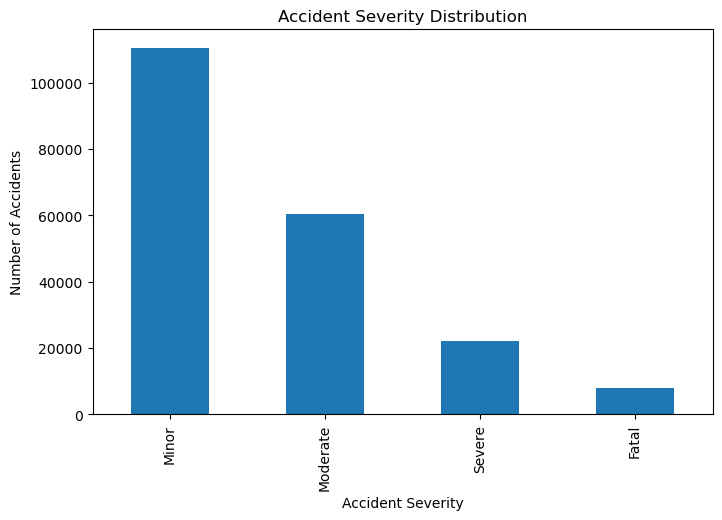

In [179]:
plt.figure(figsize=(8, 5))
x =df["accident_severity"].value_counts()
x.plot(kind="bar")

plt.title("Accident Severity Distribution")
plt.xlabel("Accident Severity")
plt.ylabel("Number of Accidents")
 
plt.show()

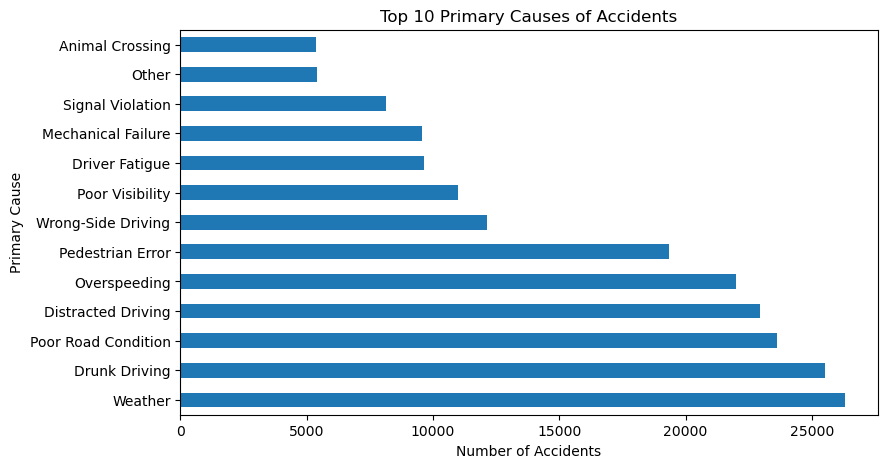

In [180]:
top_causes = df["primary_cause"].value_counts()

plt.figure(figsize=(9, 5))

top_causes.plot(kind="barh")

plt.title("Top 10 Primary Causes of Accidents")
plt.xlabel("Number of Accidents")
plt.ylabel("Primary Cause")

plt.show()

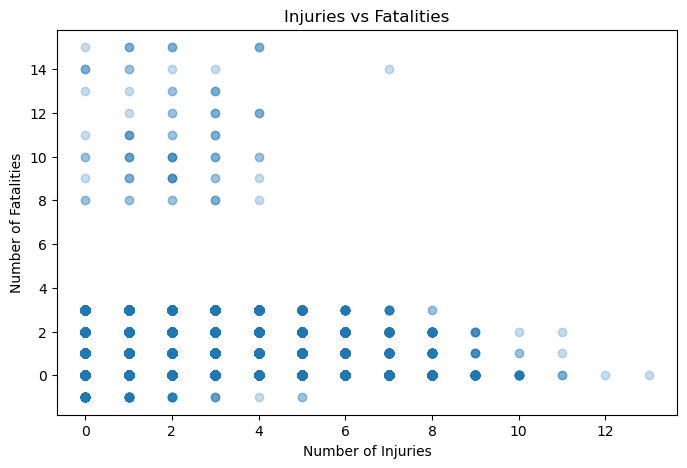

In [181]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["num_injuries"],
    df["num_fatalities"],
    alpha=0.25
)

plt.title("Injuries vs Fatalities")
plt.xlabel("Number of Injuries")
plt.ylabel("Number of Fatalities")

plt.show()

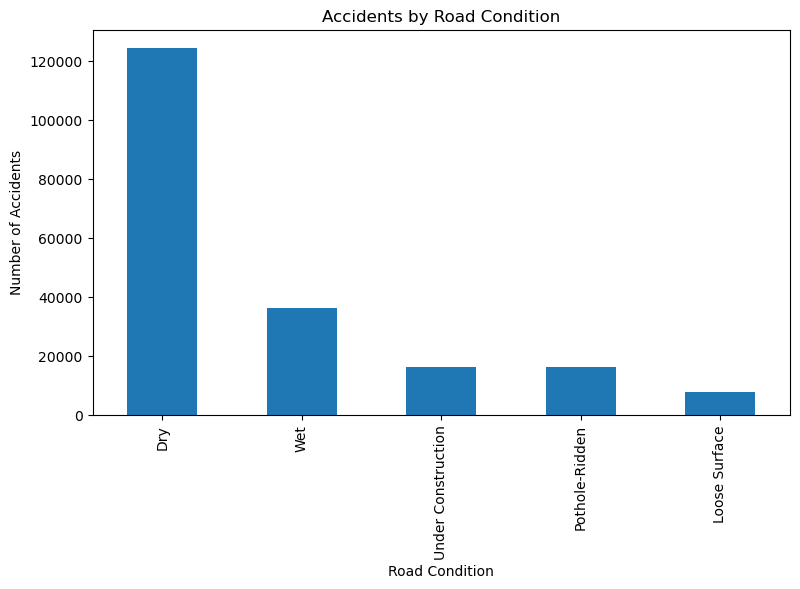

In [182]:
plt.figure(figsize=(9,5))

df["road_condition"].value_counts().plot(kind="bar")

plt.title("Accidents by Road Condition")
plt.xlabel("Road Condition")
plt.ylabel("Number of Accidents")
plt.show()

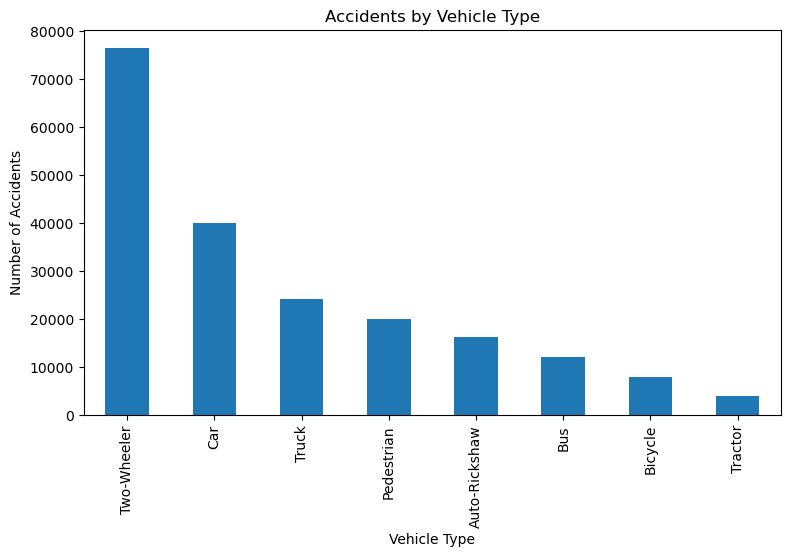

In [183]:
vehicle_counts = df["vehicle_type"].value_counts()

plt.figure(figsize=(9,5))

vehicle_counts.plot(kind="bar")

plt.title("Accidents by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Accidents")
plt.show()

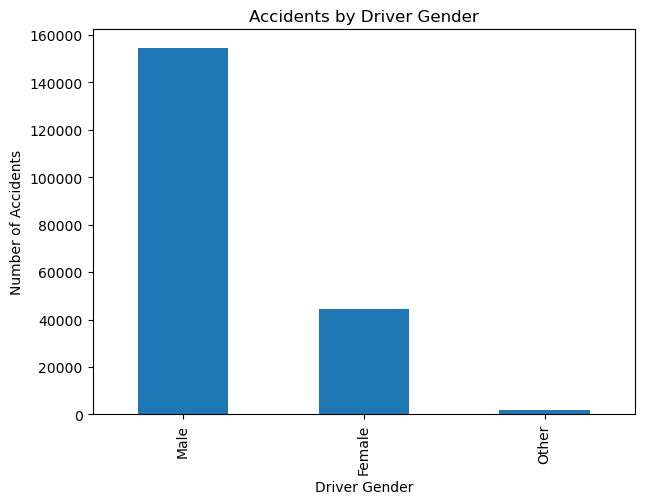

In [184]:
plt.figure(figsize=(7,5))
df["driver_gender"].value_counts().plot(
    kind="bar"
)
plt.title("Accidents by Driver Gender")
plt.xlabel("Driver Gender")
plt.ylabel("Number of Accidents")
plt.show()